In [3]:
import os

from src.data.processing_data import ProcessData
from src.models.autoencoders import AutoEncoder
from src.prediction.predict_items import PredictUserAllItems
from src.data.datasets import AutoEncoderDataset
from src.models.wrappers import AutoencoderWrapper

from torch.utils.data import DataLoader

In [4]:
N_USERS = data['DATA_DIR']['DATA_100K']['N_USERS']
N_ITEMS = data['DATA_DIR']['DATA_100K']['N_MOVIES']
TRAIN_DATASET_PATH = data['DATA_DIR']['DATA_100K']['TRAIN']
RAW_DATASET_PATH = os.path.join(data['DATA_DIR']['DATA_100K']['RAW'], 'ratings.csv')


autoencoder_dataset = AutoEncoderDataset(data_path=TRAIN_DATASET_PATH)
autoencoder_dataset_full = AutoEncoderDataset(data_path=RAW_DATASET_PATH)


autoencoder = AutoEncoder(
    io_features=N_ITEMS, hidden_dim=64
)

In [5]:
autoencoder_dataset[5].shape, autoencoder_dataset_full[5].shape

(torch.Size([7525]), torch.Size([9724]))

In [6]:
batch = next(iter(DataLoader(autoencoder_dataset_full, 64)))

In [7]:
autoencoder(batch).shape

torch.Size([64, 9724])

In [8]:
data

{'DATA_URL': {'SMALL_URL': 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip',
  'FULL_URL': 'https://files.grouplens.org/datasets/movielens/ml-latest.zip'},
 'DATA_DIR': {'DATA_100K': {'RAW': 'data/100k/raw/',
   'TRAIN': 'data/100k/train/ratings.csv',
   'TEST': 'data/100k/test/ratings.csv',
   'EVAL': 'data/100k/eval/ratings.csv',
   'SPLITS': [0.7, 0.15, 0.15],
   'N_USERS': 610,
   'N_MOVIES': 9724},
  'DATA_10M': {'RAW': 'data/10M/raw/',
   'TRAIN': 'data/10M/train/ratings.csv',
   'TEST': 'data/10M/test/ratings.csv',
   'EVAL': 'data/10M/eval/ratings.csv',
   'SPLITS': [0.8, 0.1, 0.1],
   'N_USERS': 330975,
   'N_MOVIES': 86000}}}

In [9]:
type(data['DATA_DIR']['DATA_100K']['SPLITS'][0])

float

In [10]:
type(data)

dict

In [11]:
autoencoder_wrapper = AutoencoderWrapper(
    model=autoencoder,
    config = {"lr": 0.001, "epochs": 10},
    optimizer_name='adam')

autoencoder_wrapper(batch)

tensor([[ 0.9820, -0.6737,  0.4245,  ..., -0.8900, -0.1347,  0.4424],
        [-0.0200,  0.1002, -0.5652,  ..., -0.0154,  0.1089,  0.2756],
        [ 0.2607,  0.1241,  0.2245,  ...,  0.0225,  0.1388,  0.2173],
        ...,
        [ 0.0756,  0.5476, -2.9094,  ..., -0.3605,  0.1993,  1.2961],
        [ 0.5545, -1.3427, -0.0520,  ..., -1.0895,  0.3379,  1.2792],
        [-0.2326,  0.7124, -0.6263,  ..., -1.5663,  0.1298, -0.0220]],
       grad_fn=<AddmmBackward0>)

In [12]:
autoencoder_wrapper.training_step(batch=batch, batch_idx=0)

c:\Users\ernes\miniconda3\envs\venv\Lib\site-packages\pytorch_lightning\core\module.py:451: You are trying to `self.log()` but the `self.trainer` reference is not registered on the model yet. This is most likely because the model hasn't been passed to the `Trainer`


tensor(14.4977, grad_fn=<DivBackward0>)

In [4]:
# trainer test
from src.train.trainer import Trainer, ConfigManager
from src.fine_tuning.tuner import Tuner

In [8]:
model_config_path = 'config/models_config.yaml'
hyperparams_config_path = 'config/hyperparams_config.yaml'
dataset_config_path = 'config/dataset_config.yaml'
data_dir_config_path = 'config/config.yaml'
finetuning_config_path = 'config/finetuning_config.yaml'



In [9]:
model_type = 'deep_autoencoder'
dataset_type = 'autoencoder'
dataset_type_config = 'AUTOENCODER_DATASET_CONFIG' if model_type =='autoencoder' else 'USER_ITEM_DATASET_CONFIG'
model_type_config = f"{model_type}_CONFIG".upper()


hyperparams_config = ConfigManager(hyperparams_config_path)
dataset_config = ConfigManager(dataset_config_path, config_settings=dataset_type_config)
model_config = ConfigManager(model_config_path, model_type_config)
data_dir_config = ConfigManager(data_dir_config_path)
finetuning_hparms_config = ConfigManager(finetuning_config_path)

In [4]:
model_config()

{'io_features': 9724, 'hidden_dims': [64, 64, 64], 'dropout_rate': 0.5}

In [5]:
trainer = Trainer(
    model_type=model_type,
    dataset_type=dataset_type,
    model_config=model_config,
    hyperparams_config=hyperparams_config,
    data_dir_config=data_dir_config,
    dataset_config=dataset_config,
    model_extra_config={'dropout_rate':0.6, 'hidden_dims': [128,64, 16]},
    dataset_extra_config={"batch_size":8, 'num_workers':11},
    hyperparams_extra_config={'weight_decay':1e-5, 'optimizer_name':'adamw', 'lr':1e-2},
)
trainer.train(2, save_model=False)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\ernes\miniconda3\envs\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Dataset already downloaded and extracted.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\ernes\miniconda3\envs\venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\ernes\miniconda3\envs\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\ernes\miniconda3\envs\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [6]:
trainer.evaluate()

Dataset already downloaded and extracted.


c:\Users\ernes\miniconda3\envs\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     test_loss_epoch        10.198156356811523
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss_epoch': 10.198156356811523}]

In [7]:
tuner = Tuner(
    study_name='s',
    model_type=model_type,
    finetuning_config=finetuning_hparms_config,
    n_trials=1000,
    dataset_type=dataset_type,
    model_config=model_config,
    hyperparams_config=hyperparams_config,
    data_dir_config=data_dir_config,
    dataset_config=dataset_config,
)

[I 2026-08-31 22:30:26,096] A new study created in memory with name: s


In [8]:
tuner.search_params(max_epochs=10)

  0%|          | 0/1000 [00:00<?, ?it/s]

Dataset already downloaded and extracted.


c:\Users\ernes\miniconda3\envs\venv\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:321: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Dataset already downloaded and extracted.
[I 2026-08-31 22:30:29,999] Trial 0 finished with value: 1.2969732284545898 and parameters: {'hidden_dims_nlist': 1, 'hidden_dims_1': 224, 'dropout_rate': 0.4193389785035794, 'lr': 0.0030979849723442843, 'weight_decay': 0.006977608363034034, 'batch_size': 272}. Best is trial 0 with value: 1.2969732284545898.
Dataset already downloaded and extracted.


c:\Users\ernes\miniconda3\envs\venv\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:321: The number of training batches (3) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

Dataset already downloaded and extracted.
[I 2026-08-31 23:37:07,832] Trial 805 finished with value: 1.107887864112854 and parameters: {'hidden_dims_nlist': 1, 'hidden_dims_1': 256, 'dropout_rate': 0.22826116754685283, 'lr': 0.0011462831596568742, 'weight_decay': 0.003210624534190201, 'batch_size': 48}. Best is trial 803 with value: 0.6751435995101929.
Dataset already downloaded and extracted.
Dataset already downloaded and extracted.
[I 2026-08-31 23:37:12,369] Trial 806 finished with value: 1.082417607307434 and parameters: {'hidden_dims_nlist': 1, 'hidden_dims_1': 128, 'dropout_rate': 0.2361179058016984, 'lr': 0.0012103149370894521, 'weight_decay': 0.0037391465614985166, 'batch_size': 48}. Best is trial 803 with value: 0.6751435995101929.
Dataset already downloaded and extracted.
Dataset already downloaded and extracted.
[I 2026-08-31 23:37:18,158] Trial 807 finished with value: 1.4829139709472656 and parameters: {'hidden_dims_nlist': 1, 'hidden_dims_1': 256, 'dropout_rate': 0.23841

c:\Users\ernes\miniconda3\envs\venv\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:321: The number of training batches (14) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Dataset already downloaded and extracted.
[I 2026-08-31 23:41:52,461] Trial 851 finished with value: 1.8701356649398804 and parameters: {'hidden_dims_nlist': 1, 'hidden_dims_1': 256, 'dropout_rate': 0.24956316578644253, 'lr': 0.0013942177039017788, 'weight_decay': 0.0010845634426797745, 'batch_size': 32}. Best is trial 803 with value: 0.6751435995101929.
Dataset already downloaded and extracted.
Dataset already downloaded and extracted.
[I 2026-08-31 23:41:59,623] Trial 852 finished with value: 1.0565205812454224 and parameters: {'hidden_dims_nlist': 1, 'hidden_dims_1': 256, 'dropout_rate': 0.2450293603409146, 'lr': 0.0009912243548680375, 'weight_decay': 0.00036304131434492545, 'batch_size': 56}. Best is trial 803 with value: 0.6751435995101929.
Dataset already downloaded and extracted.
Dataset already downloaded and extracted.
[I 2026-08-31 23:42:06,390] Trial 853 finished with value: 1.3868322372436523 and parameters: {'hidden_dims_nlist': 1, 'hidden_dims_1': 256, 'dropout_rate': 0.2

c:\Users\ernes\miniconda3\envs\venv\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:321: The number of training batches (27) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Dataset already downloaded and extracted.
[I 2026-08-31 23:54:29,807] Trial 973 finished with value: 3.732996702194214 and parameters: {'hidden_dims_nlist': 1, 'hidden_dims_1': 192, 'dropout_rate': 0.24908315649107315, 'lr': 0.0025825746921385303, 'weight_decay': 0.005648946746209151, 'batch_size': 16}. Best is trial 803 with value: 0.6751435995101929.
Dataset already downloaded and extracted.
Dataset already downloaded and extracted.
[I 2026-08-31 23:54:36,045] Trial 974 finished with value: 1.2408021688461304 and parameters: {'hidden_dims_nlist': 1, 'hidden_dims_1': 224, 'dropout_rate': 0.2289545349955585, 'lr': 0.0005337852597952803, 'weight_decay': 0.002626988953594353, 'batch_size': 80}. Best is trial 803 with value: 0.6751435995101929.
Dataset already downloaded and extracted.
Dataset already downloaded and extracted.
[I 2026-08-31 23:54:42,284] Trial 975 finished with value: 0.9995970129966736 and parameters: {'hidden_dims_nlist': 1, 'hidden_dims_1': 288, 'dropout_rate': 0.24058

C:\Users\ernes\AppData\Local\Temp\ipykernel_19252\368478403.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(tuner.study)


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

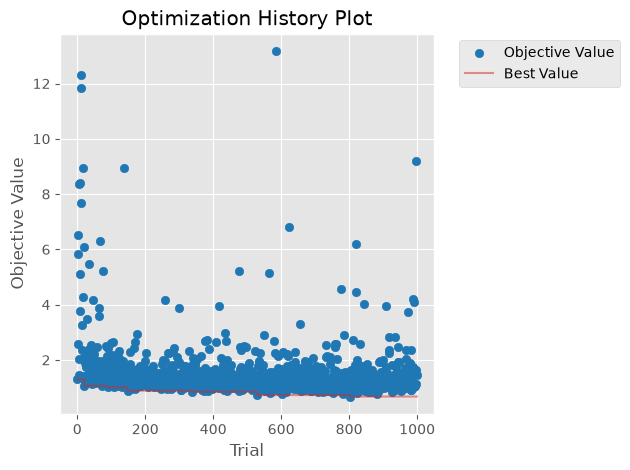

In [12]:
import optuna

optuna.visualization.matplotlib.plot_optimization_history(tuner.study)


C:\Users\ernes\AppData\Local\Temp\ipykernel_19252\3119765366.py:5: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_parallel_coordinate(tuner.study)
c:\Users\ernes\miniconda3\envs\venv\Lib\site-packages\optuna\visualization\matplotlib\_parallel_coordinate.py:120: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(dim.range[0], dim.range[1])


<Figure size 2000x1200 with 0 Axes>

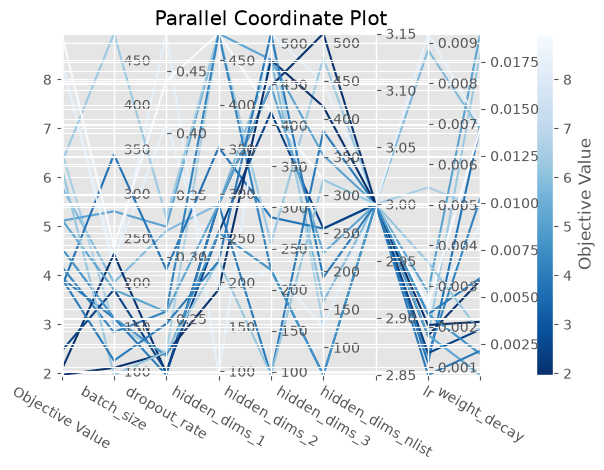

In [13]:
import matplotlib.pyplot as plt


plt.figure(figsize=(20, 12))
optuna.visualization.matplotlib.plot_parallel_coordinate(tuner.study)
plt.tight_layout()

In [14]:
tuner.study.trials_dataframe().sort_values(by='value', ascending=True).head(20)

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_dropout_rate,params_hidden_dims_1,params_hidden_dims_2,params_hidden_dims_3,params_hidden_dims_nlist,params_lr,params_weight_decay,state
803,803,0.675144,2026-08-31 23:36:48.429841,2026-08-31 23:36:54.371614,0 days 00:00:05.941773,72,0.240255,256,NaN,NaN,1,0.001186,0.003004,COMPLETE
529,529,0.729564,2026-08-31 23:16:11.962839,2026-08-31 23:16:16.968819,0 days 00:00:05.005980,136,0.291726,288,NaN,NaN,1,0.001359,0.001930,COMPLETE
783,783,0.750202,2026-08-31 23:34:50.900951,2026-08-31 23:34:56.166764,0 days 00:00:05.265813,112,0.233425,256,NaN,NaN,1,0.001496,0.002136,COMPLETE
602,602,0.773304,2026-08-31 23:21:31.927916,2026-08-31 23:21:35.720805,0 days 00:00:03.792889,168,0.219874,192,NaN,NaN,1,0.001700,0.001454,COMPLETE
883,883,0.782201,2026-08-31 23:45:21.704970,2026-08-31 23:45:27.661926,0 days 00:00:05.956956,96,0.248168,288,NaN,NaN,1,0.001337,0.001049,COMPLETE
789,789,0.796036,2026-08-31 23:35:21.979004,2026-08-31 23:35:28.512241,0 days 00:00:06.533237,96,0.239620,256,NaN,NaN,1,0.001224,0.001679,COMPLETE
822,822,0.798263,2026-08-31 23:38:45.450704,2026-08-31 23:38:49.942217,0 days 00:00:04.491513,112,0.234058,224,NaN,NaN,1,0.001407,0.004232,COMPLETE
567,567,0.801523,2026-08-31 23:19:13.342206,2026-08-31 23:19:17.588748,0 days 00:00:04.246542,184,0.223896,224,NaN,NaN,1,0.002054,0.001677,COMPLETE
753,753,0.816931,2026-08-31 23:32:27.221242,2026-08-31 23:32:31.499416,0 days 00:00:04.278174,144,0.229594,256,NaN,NaN,1,0.002341,0.003376,COMPLETE
886,886,0.826125,2026-08-31 23:45:40.018670,2026-08-31 23:45:46.270435,0 days 00:00:06.251765,96,0.259861,288,NaN,NaN,1,0.001131,0.001074,COMPLETE


In [15]:
tuner.study.best_params

{'hidden_dims_nlist': 1,
 'hidden_dims_1': 256,
 'dropout_rate': 0.2402546212253202,
 'lr': 0.0011863444178980237,
 'weight_decay': 0.003003740833647985,
 'batch_size': 72}

In [34]:
from src.data.datasets import NegSampleDataset
from torch.utils.data import DataLoader
from src.models.matrix_factorization import DeepMatrixFactorization

In [11]:
data_dir_config()

{'DATA_URL': {'SMALL_URL': 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip',
  'FULL_URL': 'https://files.grouplens.org/datasets/movielens/ml-latest.zip'},
 'DATA_DIR': {'100K': {'NAME': 'ml-latest.zip',
   'RAW': 'data/100k/raw/',
   'TRAIN': 'data/100k/train/ratings.csv',
   'TEST': 'data/100k/test/ratings.csv',
   'EVAL': 'data/100k/eval/ratings.csv',
   'SPLITS': [0.7, 0.15, 0.15],
   'N_USERS': 610,
   'N_MOVIES': 9724},
  '10M': {'NAME': 'ml-latest.zip',
   'RAW': 'data/10M/raw/',
   'TRAIN': 'data/10M/train/ratings.csv',
   'TEST': 'data/10M/test/ratings.csv',
   'EVAL': 'data/10M/eval/ratings.csv',
   'SPLITS': [0.8, 0.1, 0.1],
   'N_USERS': 330975,
   'N_MOVIES': 86000}}}

In [32]:
model_config = ConfigManager(model_config_path, 'DEEP_MATRIX_FACTORIZATION_CONFIG')
model_config()

{'n_users': 609,
 'n_items': 9724,
 'user_embedding_dim': 64,
 'item_embedding_dim': 64,
 'hidden_dims': [64, 64, 64],
 'dropout_rate': 0.5}

In [80]:

import torch
from torch import nn

class DeepMatrixFactorization(nn.Module):
    def __init__(self, n_users, n_items, user_embedding_dim, item_embedding_dim, hidden_dims:list[int], dropout_rate:float) -> None:
        super().__init__()

        self.user_embedding = nn.Embedding(num_embeddings=n_users, embedding_dim=user_embedding_dim)
        self.item_embedding = nn.Embedding(num_embeddings=n_items, embedding_dim=item_embedding_dim)

        fc = [nn.Linear(in_features=user_embedding_dim + item_embedding_dim, out_features=hidden_dims[0]),
                                      nn.ReLU(), 
                                      nn.Dropout(dropout_rate)]

        for prev_hidden, pos_hidden in zip(hidden_dims[:-1], hidden_dims[1:]):
            fc.append(nn.Linear(in_features=prev_hidden, out_features=pos_hidden))
            fc.append(nn.ReLU())
            fc.append(nn.Dropout(dropout_rate))

        fc.append(nn.Linear(in_features=hidden_dims[-1], out_features=1))
        self.fc = nn.Sequential(*fc)

        self.apply(self._init_weights)


    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
            if module.bias is not None:
                nn.init.constant_(module.bias, 0.0)


    def forward(self, user_id, item_id):
        user_embedded = self.user_embedding(user_id)
        item_embedded = self.item_embedding(item_id)

        x = torch.cat([user_embedded, item_embedded], dim=-1)
        print(x.shape)
        #x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

In [81]:
dmf = DeepMatrixFactorization(**model_config()
)

In [47]:
neg_sample_data = NegSampleDataset(data_dir_config()['DATA_DIR']['100K']['TRAIN'])
neg_sample_loader = DataLoader(neg_sample_data, 8, shuffle=True)

In [73]:
neg_sample_data[0]

(tensor(1), tensor(804), tensor(4.), tensor([3444, 4523, 7304, 2623]))

In [66]:
user_indices, item_indices, ratings, neg_samples = next(iter(neg_sample_loader))

user_indices.shape, item_indices.shape, ratings.shape, neg_samples.shape

(torch.Size([8]), torch.Size([8]), torch.Size([8]), torch.Size([8, 4]))

In [74]:
s = torch.concat([item_indices.unsqueeze(1), neg_samples], dim=1)
s.shape

torch.Size([8, 5])

In [75]:
item_indices

tensor([2617, 5028, 1204, 5288, 3671,  368, 2942, 2395])

In [76]:
user_indices.unsqueeze(1).expand((8, 4))

tensor([[  1,   1,   1,   1],
        [567, 567, 567, 567],
        [590, 590, 590, 590],
        [462, 462, 462, 462],
        [448, 448, 448, 448],
        [249, 249, 249, 249],
        [ 47,  47,  47,  47],
        [562, 562, 562, 562]])

In [83]:
output = dmf(user_indices.unsqueeze(1).expand((s.shape)), s)
output.shape

torch.Size([8, 5, 128])


torch.Size([8, 5, 1])

In [ ]:
nn.MSELoss()()

In [87]:
output

tensor([[[ 7.7910e+01],
         [ 6.2857e+01],
         [ 9.2418e+01],
         [ 5.8622e+01],
         [ 3.8572e+01]],

        [[ 1.3146e+01],
         [ 1.3650e+01],
         [ 6.1858e+01],
         [ 2.0724e+01],
         [ 4.0378e+01]],

        [[ 1.5250e+00],
         [-2.4381e+01],
         [-5.2190e+00],
         [-1.4548e+01],
         [ 3.6976e+01]],

        [[ 8.8663e+00],
         [ 3.6679e+01],
         [-3.0221e+01],
         [ 9.2124e+00],
         [ 8.5162e+01]],

        [[ 7.0990e+01],
         [-3.1308e+00],
         [ 3.1301e+01],
         [ 4.0053e+00],
         [ 1.6692e-01]],

        [[ 2.6610e+00],
         [ 8.9599e+01],
         [-3.5305e+01],
         [ 1.1783e+02],
         [ 1.7435e+02]],

        [[ 1.1845e+02],
         [-1.6073e+01],
         [ 3.9075e+01],
         [-3.0989e+01],
         [ 2.3023e+01]],

        [[ 2.8181e+01],
         [ 1.9151e+01],
         [ 1.1121e+02],
         [-3.4967e+01],
         [-1.1452e+00]]], grad_fn=<ViewBackward0>)

In [88]:
dmf(user_indices, item_indices).shape

torch.Size([8, 128])


torch.Size([8, 1])